In [7]:
#analysing ecommerce sales drop

*company scenario*:
flipkart/amazon
we r seeing  a drop in revenue , find the reason and suggest actions

In [8]:
#importing necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#reading the data
customers = pd.read_csv("/content/customers.csv")
orders = pd.read_csv("/content/orders.csv")
products = pd.read_csv("/content/products.csv")


EDA

In [10]:
df = pd.merge(customers,orders,on='customer_id',how='inner')
df = pd.merge(df,products,on='product_id',how='inner')
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [12]:
#converting date columns into date-time format
df["signup_date"] = pd.to_datetime(df['signup_date'])
df["order_date"] = pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [13]:
#creating revenue column
#formula: revenue = price * quantity
df['revenue'] = df['price'] * df['quantity']
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


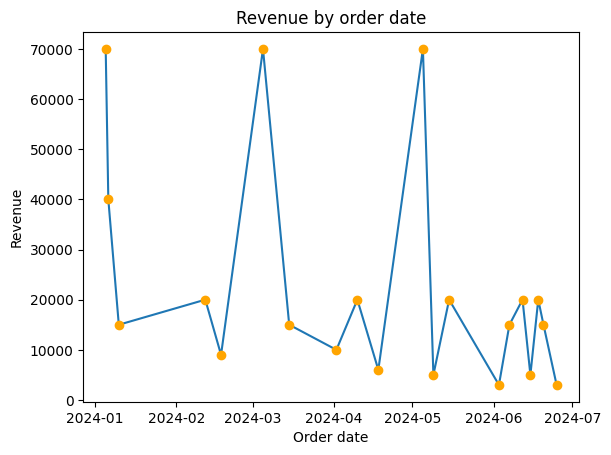

In [14]:
#Revenue trend by order date
revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("Order date")
plt.ylabel("Revenue")
plt.title("Revenue by order date")
plt.show()

the revenue is very less in the last 2 months - june and july

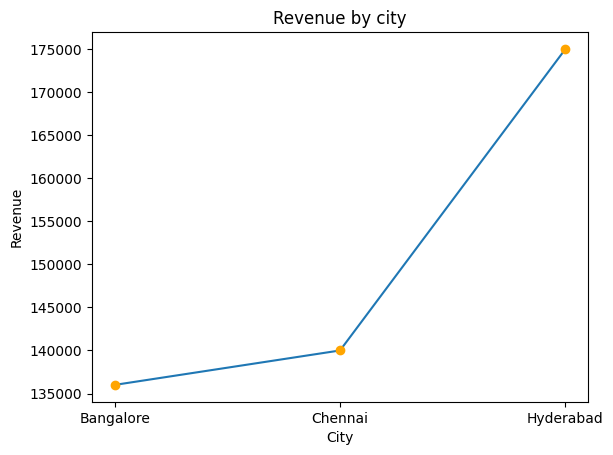

In [17]:
#Revenue trend by city
revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["city"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by city")
plt.show()

**Revenue is dropping in Banglore**

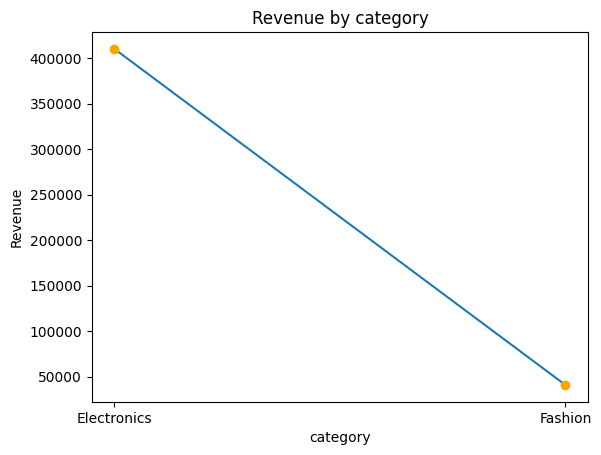

In [18]:
#Revenue trend by category
revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["category"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue by category")
plt.show()

**In Fashion category revenue got dropped**

In [19]:
#count customers based on order_id(count of orders per customer)
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**Most of the customers are ordering less**

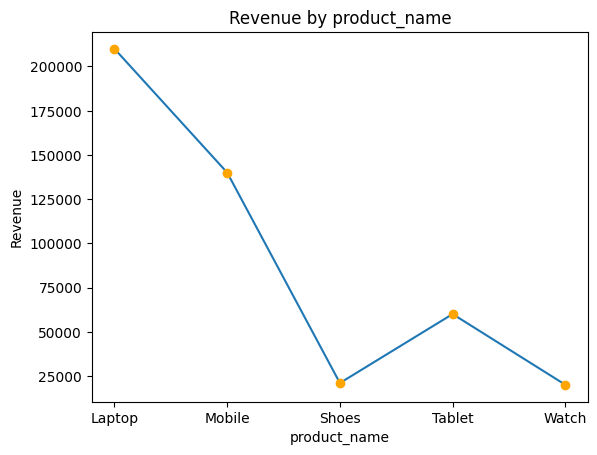

In [20]:
#Revenue trend by product_name
revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue by product_name")
plt.show()

**Revenue is very less for shoes and watch**

# Insights:
1) revenue got dropped in last 2 motnhs(jun,jul)
2) banglore contributed more in revenue drop
3) fashin category recorded less revenue
4) repeated customers ordered less
5) shoes and watch sales declined significantly

#recommendations:
1) nice marketing should be done in banglore
2) provide discount for shoe and watch
3) coupens , discounts and loyalty programs for repeated customers